In [1]:
import xarray as xr
import numpy as np
import datetime
import pandas as pd
import matplotlib
from shapely import LineString
import matplotlib.pyplot as plt
from matplotlib import cm
from shapelysmooth import chaikin_smooth
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle, Wedge
from matplotlib.ticker import FormatStrFormatter
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from argopy import ArgoIndex
#import seaborn as sns
#colors : continents, oceans, wedge/graph, active
mcolors = ['#0d1b2a','#415a77','#ffffff','#8ecae6']
float_color = [255./255,255./255,255./255]
#mcolors = ['#38a3a5','#251f47','#c9ffe2','#38a3a5']

In [2]:
import sys
sys.path.insert(0, "argotrajplot/")
from argotrajplot import Styler, pltraj

In [3]:
styler = Styler(ocean_color='lightblue', land_color='gray', trajectory_color='red', line_width=1, dpi=100, figsize=(10, 6))

In [4]:
styler.to_dict()

{'ocean_color': 'lightblue',
 'land_color': 'gray',
 'trajectory_color': 'red',
 'line_width': 1,
 'dpi': 100,
 'figsize': (10, 6)}

In [5]:
box = [-180, 180, -90, 90, '2007-01', '2008-01']
idx = ArgoIndex()
DST = idx.query.box(box).to_dataframe()
DST

,file,date,latitude,longitude,ocean,profiler_code,institution_code,date_update,wmo,cyc,institution,dac,profiler
0,aoml/1900044/profiles/D1900044_143.nc,2007-01-07 18:41:34,-52.980,150.380,P,846,AO,2015-02-27 13:35:18,1900044,143,"AOML, USA",aoml,Teledyne Webb Research float with SBE conducti...
1,aoml/1900044/profiles/D1900044_144.nc,2007-01-18 08:03:24,-52.540,152.345,P,846,AO,2015-02-27 13:35:19,1900044,144,"AOML, USA",aoml,Teledyne Webb Research float with SBE conducti...
2,aoml/1900044/profiles/D1900044_145.nc,2007-01-28 23:26:04,-54.166,154.855,P,846,AO,2015-02-27 13:35:19,1900044,145,"AOML, USA",aoml,Teledyne Webb Research float with SBE conducti...
3,aoml/1900044/profiles/D1900044_146.nc,2007-02-08 09:34:46,-53.361,157.263,P,846,AO,2015-02-27 13:35:19,1900044,146,"AOML, USA",aoml,Teledyne Webb Research float with SBE conducti...
4,aoml/1900044/profiles/D1900044_147.nc,2007-02-18 22:36:46,-51.631,157.097,P,846,AO,2015-02-27 13:35:19,1900044,147,"AOML, USA",aoml,Teledyne Webb Research float with SBE conducti...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
108975,meds/4901084/profiles/D4901084_005.nc,2007-11-16 20:31:00,41.156,-62.384,A,846,ME,2025-12-15 16:26:28,4901084,5,"MEDS, Canada",meds,Teledyne Webb Research float with SBE conducti...
108976,meds/4901084/profiles/D4901084_006.nc,2007-11-26 20:07:00,40.838,-62.208,A,846,ME,2025-12-15 16:26:28,4901084,6,"MEDS, Canada",meds,Teledyne Webb Research float with SBE conducti...
108977,meds/4901084/profiles/D4901084_007.nc,2007-12-07 00:13:00,41.012,-62.288,A,846,ME,2025-12-15 16:26:28,4901084,7,"MEDS, Canada",meds,Teledyne Webb Research float with SBE conducti...
108978,meds/4901084/profiles/D4901084_008.nc,2007-12-17 00:06:00,41.167,-62.930,A,846,ME,2025-12-15 16:26:28,4901084,8,"MEDS, Canada",meds,Teledyne Webb Research float with SBE conducti...


In [6]:
fig = pltraj(fig, DST, projection=ccrs.Mercator(),styler=styler)

Error in callback <function _draw_all_if_interactive at 0x7e84c7bca4d0> (for post_execute), with arguments args (),kwargs {}:


AttributeError: 'numpy.ndarray' object has no attribute 'is_empty'

AttributeError: 'numpy.ndarray' object has no attribute 'is_empty'

<Figure size 2250x1080 with 1 Axes>

In [4]:
# number of floats deployed in year
deployed = len(DST.groupby('wmo').first())
# number of profiles in year
profiles = len(DST)
print(deployed,profiles)

3472 108980


In [5]:
platf=np.unique(DST.wmo.values)  
platf

array([  19019,   19021,   29003, ..., 7900176, 7900177, 7900178],
      shape=(3472,))

In [14]:
def gen_LineObj(pl):
    DS1b=DST[DST.wmo.isin([pl])]
    if(len(DS1b)>1):     
        A = ccrs.Spilhaus().transform_points(ccrs.PlateCarree(), DS1b.longitude.values, DS1b.latitude.values )          
        Di=np.sqrt((A[0:-1,0]-A[1:,0])**2+(A[0:-1,1]-A[1:,1])**2)
        if np.max(Di)<500000:            
            B = LineString(A[:,0:2])
            C = chaikin_smooth(B)
            return C
        else :
            pass        
    else:
        pass

In [15]:
import multiprocessing
#DATE TO PROCESS
pool = multiprocessing.Pool()       
#data = pool.map(gen_traj, platf)
data = pool.map(gen_LineObj, platf)
pool.close()
pool.join()

In [16]:
data = np.array(data)
data = data[data!=None]
data

array([<LINESTRING (-5485362.405 226523.357, -5493176.711 220026.011, -5493646.537 ...>,
       <LINESTRING (-3429109.864 461566.474, -3431385.424 456082.231, -3431521.226 ...>,
       <LINESTRING (9602253.043 -4642397.552, 9583365.086 -4668038.071, 9582324.202...>,
       ...,
       <LINESTRING (-4956757.53 6989795.708, -4950112.262 7000975.859, -4949732.784...>,
       <LINESTRING (-4938915.746 7007307.986, -4941736.709 7019178.98, -4941918.134...>,
       <LINESTRING (-4640534.418 7525980.495, -4619036.703 7529397.828, -4617795.88...>],
      shape=(3398,), dtype=object)

In [9]:
def colorize_line(geometry):    
    return {'facecolor': 'none', 'edgecolor': float_color, 'linewidth':.2}

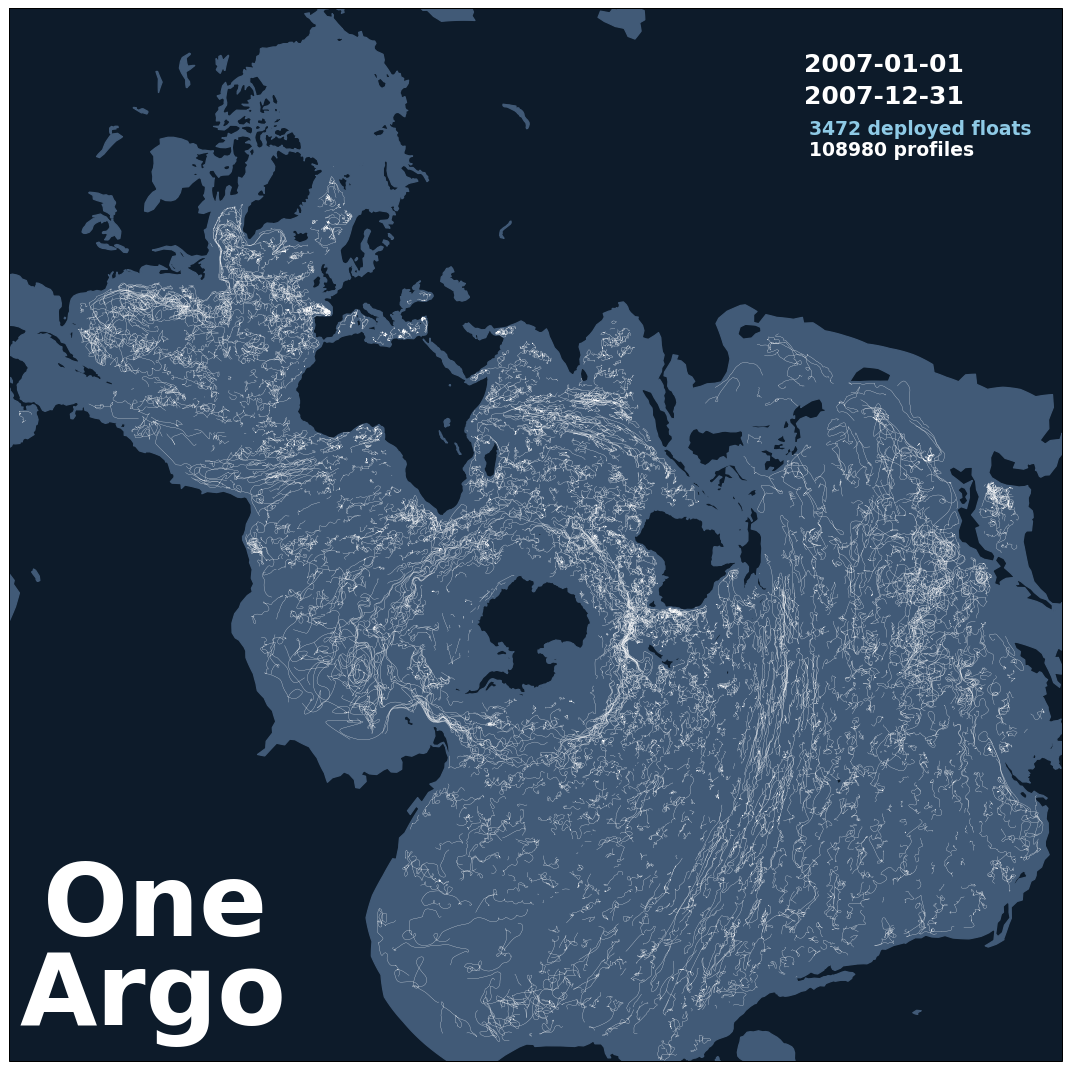

In [17]:
# PLOT
fig = plt.figure(figsize=(25,12),dpi=90)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Spilhaus())
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor=mcolors[0],edgecolor=mcolors[0])
ax.add_feature(cfeature.OCEAN,facecolor=mcolors[1],edgecolor=mcolors[1])
ax.add_feature(cfeature.LAKES,facecolor=mcolors[1],edgecolor=mcolors[1])    

ax.text(0.0325,0.12,'One',weight='bold', size=80, color=mcolors[2], transform=ax.transAxes)
ax.text(0.01,0.035,'Argo',weight='bold', size=80, color=mcolors[2], transform=ax.transAxes)
ax.text(0.755,0.94,str(DST.date.min())[:10],weight='bold', size=20, color=mcolors[2], transform=ax.transAxes)
ax.text(0.755,0.91,str(DST.date.max())[:10],weight='bold', size=20, color=mcolors[2], transform=ax.transAxes)
ax.text(0.76,0.88,str(int(deployed))+' deployed floats',weight='bold', size=15, color=mcolors[3], transform=ax.transAxes)
ax.text(0.76,0.86,str(int(profiles))+' profiles',weight='bold', size=15, color=mcolors[2], transform=ax.transAxes)

ax.add_geometries(data, ccrs.Spilhaus(),styler=colorize_line)

plt.tight_layout()   
plt.show()
#plt.savefig('EK_24.png')

In [24]:
year_to_process = np.datetime64('2024')

In [25]:
DS=xr.open_dataset('Argo_world_full_202504.nc')
DST=xr.Dataset({'latitude':('time',DS.latitude.values),
                'longitude':('time',DS.longitude.values),
                'platform_number':('time',DS.platform_number.values),
                'institution':('time',DS.institution.values),
               },coords={'time':DS.time.values})
DST=DST.where((DST.time>=year_to_process)&(DST.time<year_to_process+np.timedelta64(1,'Y')),drop=True)          
DST=DST.where((~np.isnan(DST.latitude))&(~np.isnan(DST.longitude)),drop=True)
DST=DST.where(DST['latitude']!=0.0,drop=True)
DST=DST.where(DST['longitude']!=0.0,drop=True)
# number of floats deployed in year
deployed = len(DST.groupby('platform_number').first().platform_number)
# number of profiles in year
profiles = len(DST.time)
print(deployed,profiles)
DST

4692 167879


<xarray.Dataset> Size: 5MB
Dimensions:          (time: 167879)
Coordinates:
  * time             (time) datetime64[ns] 1MB 2024-01-01T00:02:00 ... 2024-1...
Data variables:
    latitude         (time) float32 672kB 36.92 -56.17 -3.507 ... -20.67 -35.86
    longitude        (time) float32 672kB 18.04 -173.1 -172.3 ... 85.5 27.38
    platform_number  (time) float64 1MB 5.907e+06 5.907e+06 ... 6.904e+06
    institution      (time) object 1MB 'IF' 'AO' 'AO' 'AO' ... 'IF' 'CS' 'IF'

In [26]:
platf=np.unique(DST.platform_number.values)  
platf

array([1901514., 1901701., 1901727., ..., 7902257., 7902258., 7902287.],
      shape=(4692,))

In [18]:
def gen_LineObj(pl):
    DS1b=DST.where(DST.platform_number.isin([pl]),drop=True)
    if(len(DS1b.time)>1):     
        A = ccrs.Spilhaus().transform_points(ccrs.PlateCarree(), DS1b.longitude.values, DS1b.latitude.values )          
        Di=np.sqrt((A[0:-1,0]-A[1:,0])**2+(A[0:-1,1]-A[1:,1])**2)
        if np.max(Di)<500000:
            A = ccrs.Spilhaus().transform_points(ccrs.PlateCarree(), DS1b.longitude.values, DS1b.latitude.values )            
            B = LineString(A[:,0:2])
            C = chaikin_smooth(B)
            return C
        else :
            pass        
    else:
        pass

In [27]:
import multiprocessing
#DATE TO PROCESS
pool = multiprocessing.Pool()       
#data = pool.map(gen_traj, platf)
data = pool.map(gen_LineObj, platf)
pool.close()
pool.join()

In [28]:
data = np.array(data)
data = data[data!=None]
data

array([<LINESTRING (-1334500.134 2829364.709, -1334266.321 2829477.936, -1334253.39...>,
       <LINESTRING (-401348.804 842879.449, -409981.06 839648.501, -410498.931 8394...>,
       <LINESTRING (-3397080.273 1337097.746, -3396189.849 1331509.047, -3396132.36...>,
       ...,
       <LINESTRING (719057.375 2677237.885, 725784.632 2664342.636, 726219.355 2663...>,
       <LINESTRING (1600016.089 -2291629.812, 1600286.76 -2292196.746, 1600304.62 -...>,
       <LINESTRING (-4673990.191 5226295.229, -4673990.191 5226295.229, -4673990.19...>],
      shape=(4605,), dtype=object)

In [22]:
def colorize_line(geometry):    
    return {'facecolor': 'none', 'edgecolor': float_color, 'linewidth':.2}

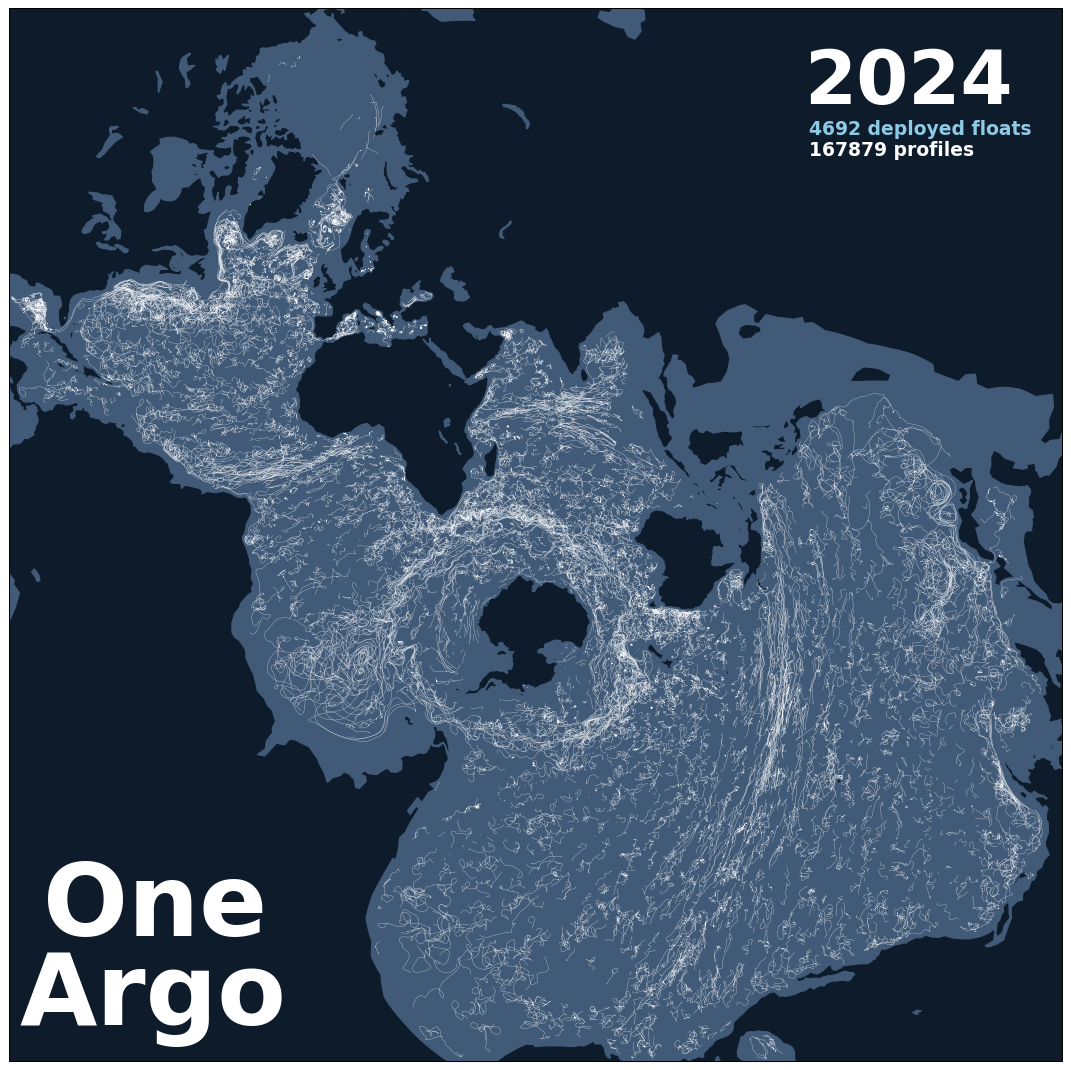

In [31]:
# PLOT
fig = plt.figure(figsize=(25,12),dpi=90)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Spilhaus())
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor=mcolors[0],edgecolor=mcolors[0])
ax.add_feature(cfeature.OCEAN,facecolor=mcolors[1],edgecolor=mcolors[1])
ax.add_feature(cfeature.LAKES,facecolor=mcolors[1],edgecolor=mcolors[1])    

ax.text(0.0325,0.12,'One',weight='bold', size=80, color=mcolors[2], transform=ax.transAxes)
ax.text(0.01,0.035,'Argo',weight='bold', size=80, color=mcolors[2], transform=ax.transAxes)
ax.text(0.755,0.91,str(year_to_process),weight='bold', size=60, color=mcolors[2], transform=ax.transAxes)
ax.text(0.76,0.88,str(int(deployed))+' deployed floats',weight='bold', size=15, color=mcolors[3], transform=ax.transAxes)
ax.text(0.76,0.86,str(int(profiles))+' profiles',weight='bold', size=15, color=mcolors[2], transform=ax.transAxes)

ax.add_geometries(data, ccrs.Spilhaus(),styler=colorize_line)

plt.tight_layout()   
#plt.show()
plt.savefig('EK_24.png')